# Final Exam, DSCI 311 Fall 25
## Due Date: Friday 12/12 by 9:00 AM PST

**Collaboration Policy: No collaboration is allowed on this test. All work must be your own.**

**Chat GPT and other AI**: The use of AI tools is forbidden on this exam. If asked, you should be prepared to explain how any piece of code works and why you wrote it the way you did. 

**Note that for ALL plotting questions, we will expect appropriate titles, axis labels, legends, etc. The following question serves as a good guideline on what is "enough": If I directly downloaded the plot and viewed it, would I be able to tell what was being visualized without knowing the question?** 

This final covers most topics touched on in the course, as well as one or two covered in DSCI 102. You should feel free to use: past homeworks, labs, lecture slides, lecture notebooks, class textbooks and even google/stack overflow/AI to help you answer these questions.

You may be expected to do things that we have not explicitly shown in class or in an assignment - this is intentional, and why we expect you to reference function documentation (*e.g.* `help(pd.read_csv)`) or internet resources (e.g. Stack Overflow/AI) for help. But most of what you will do will have been shown either in lecture (in slides or in lecture notebooks) or in assignments.

We provide cells for your answers but you should break out your answers into as many cells as you'd like to answer them.

**Grader tests**: There are no grader tests in the final. Be sure to read all questions carefully.

When you are finished, please 'Restart and Clear Output' in the Kernel Menu
Then execute **every** code cell.
Then 'Save and Checkpoint' in the File Menu, followed by 'Close and Halt' in the File Menu
Then submit your fully executed notebook to the Canvas Final assignment

**You must submit by 9:00am on Friday, 12 December**. I strongly recommend you submit the exam by Thursday evening in the event you run into any issues with Canvas.

In [166]:
# import all modules that you require here
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss

## Part 1: Oregon Fires Over Time

The following data contains records of every wildfire in Oregon between 2000 and 2022. All of us at this point are familiar with fire season in the late summer in Eugene - it would be interesting to evaluate trends in these fires over time! 

First read in `ODF_Fire_occurence_Data_2000-2022.csv`, which contains various descriptive variables pertaining to every wildfire during this timeframe.

In [167]:
fire = pd.read_csv("data/ODF_Fire_Occurrence_Data_2000-2022.csv")
fire.columns

Index(['Serial', 'FireCategory', 'Area', 'DistrictName', 'UnitName',
       'FullFireNumber', 'FireName', 'Size_class', 'EstTotalAcres',
       'Protected_Acres', 'HumanOrLightning', 'CauseBy', 'GeneralCause',
       'SpecificCause', 'Cause_Comments', 'Lat_DD', 'Long_DD', 'LatLongDD',
       'FO_LandOwnType', 'Twn', 'Rng', 'Sec', 'Subdiv', 'LandmarkLocation',
       'County', 'RegUseZone', 'RegUseRestriction', 'Industrial_Restriction',
       'Ign_DateTime', 'ReportDateTime', 'Discover_DateTime',
       'Control_DateTime', 'CreationDate', 'ModifiedDate', 'DistrictCode',
       'UnitCode', 'DistFireNumber'],
      dtype='object')

In [168]:
fire.head()

,Serial,FireCategory,Area,DistrictName,UnitName,FullFireNumber,FireName,Size_class,EstTotalAcres,Protected_Acres,...,Industrial_Restriction,Ign_DateTime,ReportDateTime,Discover_DateTime,Control_DateTime,CreationDate,ModifiedDate,DistrictCode,UnitCode,DistFireNumber
0,102649,STAT,EOA,Klamath-Lake,Klamath,15-981082-16,Bass 497,B,3.20,3.20,...,Does Not Apply - Eastern OR,9/2/2015 17:00,9/2/2015 17:05,9/2/2015 17:00,9/2/2015 23:00,9/5/2015 0:00,10/13/2015 8:39,98,981,82
1,131239,STAT,EOA,Walker Range - WRFPA,Crescent,22-991220-23,Hay Fire,A,NaN,0.20,...,NaN,NaN,8/16/2022 18:56,NaN,NaN,8/18/2022 0:00,8/18/2022 9:11,99,991,220
2,58256,STAT,EOA,Central Oregon,John Day,00-952011-01,Slick Ear #2,B,0.75,0.75,...,Does Not Apply - Eastern OR,7/18/2000 19:00,7/19/2000 13:20,7/19/2000 13:15,7/20/2000 0:50,7/20/2000 9:13,11/14/2000 9:16,95,952,11
3,59312,STAT,EOA,Northeast Oregon,La Grande,00-971024-01,Woodley,C,80.00,80.00,...,Does Not Apply - Eastern OR,8/24/2000 5:30,8/24/2000 13:07,8/24/2000 13:07,9/1/2000 21:30,8/29/2000 15:59,12/21/2000 16:22,97,971,24
4,61657,STAT,SOA,Southwest Oregon,Grants Pass,01-712133-02,QUEENS BRANCH,A,0.10,0.10,...,Lvl 3 Restricted Shutdown,8/10/2001 17:40,8/10/2001 17:47,8/10/2001 17:45,8/10/2001 18:30,8/10/2001 18:42,8/17/2001 11:45,71,712,133


#### Question 1.1

To analyze trends through time, we'll first need to create two new columns in `fire` called "Year" and "Year_Month". Derive these variables from `ReportDateTime` by whatever means you'd like.

In [169]:
fire["ReportDateTime"] = pd.to_datetime(fire["ReportDateTime"])
fire['Year'], fire['Year_Month'] = fire["ReportDateTime"].apply(lambda x: x.year), fire["ReportDateTime"].apply(lambda x: x.month)


#### Question 1.2

Now plot a time series of the total number of fires for each year and month combination in the data. The values should be plotted in chronological order i.e. March 2000 should be the first month and November 2022 the last. Don't worry about making the x axis labels readable.

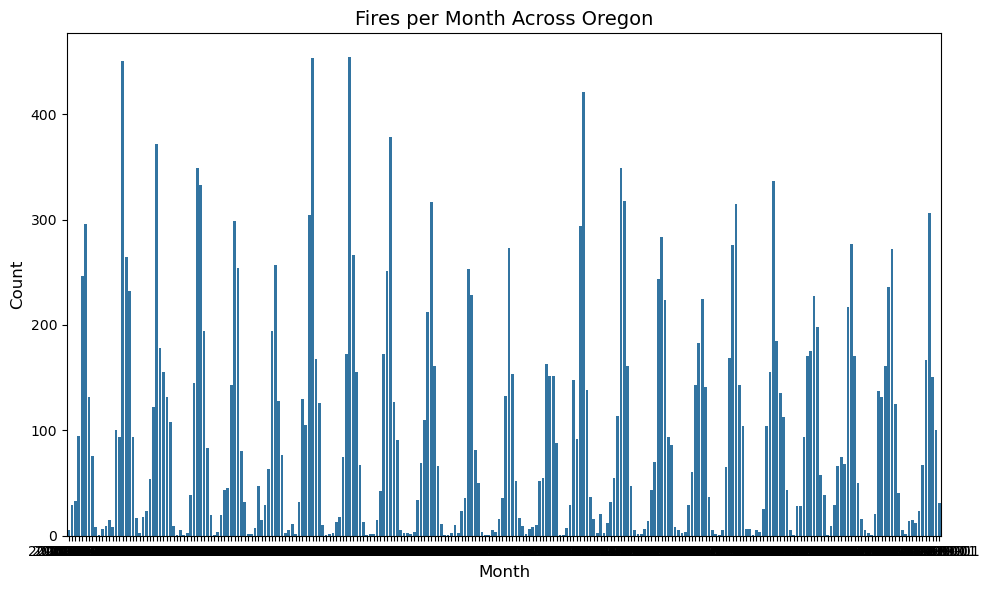

In [170]:
monthly = fire.groupby(["Year", "Year_Month"]).size().reset_index(name='Count')
monthly['Date'] = pd.to_datetime(monthly['Year'].astype(str) + '-' + monthly['Year_Month'].astype(str))
plt.figure(figsize=(10, 6))
sns.barplot(data=monthly, x="Date", y="Count")
plt.xlabel('Month', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Fires per Month Across Oregon', fontsize=14)
plt.tight_layout()
plt.show()

What are two things you observe about fires through time

**Your response**: 
- The peaks number of fires is pretty consistent, with growth in May, spikes through the summer, and finally a decline in September/October.
- Seasonal fire cycles can perhaps be grouped; often, after a peak year, the number of peak fires in the following years declines for a handful of years before spiking again.

#### Question 1.3

Sum the total acreage burned in each year (`EstTotalAcres`), then visualize the association with a seaborn `regplot`. Ensure that the confidence interval around the best-fit line is visible. Then, based on the line and visualized confidence interval, how confident do you feel in the slope?

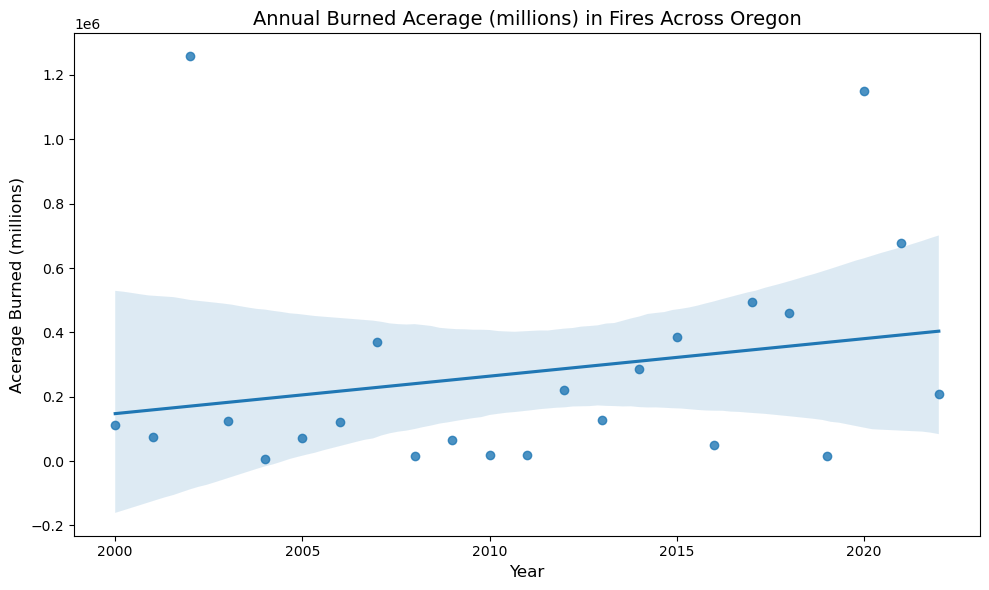

In [171]:
acres = fire.groupby(["Year"]).agg(
    Acreage=('EstTotalAcres', 'sum')
).reset_index()
plt.figure(figsize=(10, 6))
sns.regplot(data=acres, x="Year", y="Acreage")
plt.xlabel('Year', fontsize=12)
plt.ylabel('Acerage Burned (millions)', fontsize=12)
plt.title('Annual Burned Acerage (millions) in Fires Across Oregon', fontsize=14)
plt.tight_layout()
plt.show()

**Your response**: The slope seems to be positive, i.e. depicting an increase in burned acerage over time, but I don't feel very confident in this. The confidence interval often approaches +/- a quarter million, larger than most fires, though a slight majority of data points fall within the confidence interval (not enough to make me confident, however). There are also two major outliers that could be affecting this that have a burned acerage > 1,000,000 acres.

#### Question 1.4

You should see a generally positive association between the two variables. However, we don't conclude anything statistical from visualization alone. 

Use [statsmodels](https://www.statsmodels.org/stable/index.html) to fit linear a model and evaluate the summary output. What is your confidence in the slope of the line in terms of the p-value and confidence interval?

In [172]:
model = smf.ols(formula='Acreage~Year', data=acres).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                Acreage   R-squared:                       0.053
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     1.166
Date:                Thu, 11 Dec 2025   Prob (F-statistic):              0.293
Time:                        20:52:37   Log-Likelihood:                -324.75
No. Observations:                  23   AIC:                             653.5
Df Residuals:                      21   BIC:                             655.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -2.315e+07   2.17e+07     -1.067      0.2

**Your response**: What jumps out to me immediately is that the p-value is 0.293, which is much higher than the usual 0.05 significance threshold. Additionally, the confidence interval ranges from ~ -10,000 to 34,000, which is terrible as it crosses 0, meaning the true slope could be positive or negative. These considerations make me not confident in the slope.

#### Question 1.5

Returning to the scatterplot, there does appear to be a pretty considerable outlier early in the time series. Filter that point out of the data, then repeat q1.4.

In [173]:
acres_clean = acres.drop(2, axis='index')

In [174]:
model = smf.ols(formula='Acreage~Year', data=acres_clean).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                Acreage   R-squared:                       0.298
Model:                            OLS   Adj. R-squared:                  0.263
Method:                 Least Squares   F-statistic:                     8.489
Date:                Thu, 11 Dec 2025   Prob (F-statistic):            0.00859
Time:                        20:52:37   Log-Likelihood:                -302.44
No. Observations:                  22   AIC:                             608.9
Df Residuals:                      20   BIC:                             611.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -4.54e+07   1.57e+07     -2.899      0.0

How does removing the outlier change your confidence in the slope? Do you think it's valid to remove the outlier in this case? Justify your answer.

**Your response**: With the outlier removed, the p value shrinks to 0.009 and the confidence interval, while quite wide, is entirely positive now. This gives me much greater confidence in the slope. I think it's valid to remove the outlier in this case as it doesn't really follow any sort of trend amongst its surrounding points (unlike, say, 2020) and is so extreme in its deviation. A more robust statistical method would be useful in justifying its removal, however, such as using its z-score.

#### Question 1.6

For this question, we're going to compare the burn times of fires started by humans and fires started by lightning. 

1. Create a new variable called `Burn_time_days` that represents the time difference between `Control_DateTime` and `ReportDateTime` in units of days. Because there are a few erroneous date entries that render a negative difference, subset the resulting data for only burn times greater than 0.
2. Visualize two overlapping distributions of the **log-transformed** burn times of human-started fires vs lightning-started fires (`HumanOrLightning` in the data). Ensure the distributions are different colors.

In [175]:
fire['Control_DateTime'] = pd.to_datetime(fire['Control_DateTime'])
fire['Burn_time_days'] = (fire["Control_DateTime"] - fire["ReportDateTime"]).dt.days
fire_clean = fire[fire['Burn_time_days'] > 0]

<Figure size 1000x600 with 0 Axes>

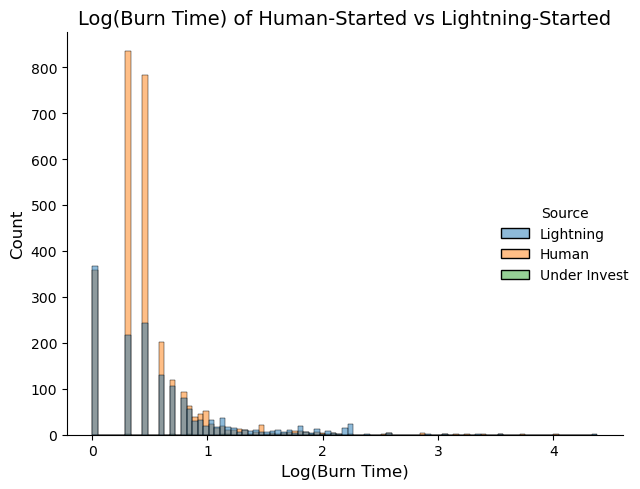

<Figure size 640x480 with 0 Axes>

In [176]:
plt.figure(figsize=(10, 6))
g = sns.displot(data=fire_clean, x=fire_clean['Burn_time_days'].apply(np.log10), hue="HumanOrLightning")
g.set_axis_labels('Log(Burn Time)', 'Count', fontsize=12)
g._legend.set_title('Source')
plt.title('Log(Burn Time) of Human-Started vs Lightning-Started', fontsize=14)
plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()

How do fires of different ignition sources differ? Describe in terms of characteristics of the distributions. 

And is there anything odd about the distributions? If so, provide a plausible interpretation.

**Your response**: Both distributions appear to be approximately exponential, meaning all fires tend to be short. It appears that human-started fires tend to be shorter compared to lightning-started fires, as that distribution peaks to a much greater extent at around 0.5 days, though very short fires see about an equal proportion of human and lightning starts. The proportion of fires that are lightning-started increases greatly for fires > 0.5 days; the right tail of the lightning distribution is higher and longer than the tail of the human distribution. I think it's odd that the human distribution peaks so much more and so much lower than the lightning distribution. Perhaps this is because human fires tend to occur in populated areas or accessible places like campgrounds, meaning responses are likely to be quicker.

## Part 2: COVID Excess Mortality

You may remember that COVID was once a big deal, killing 1.2+ million people in the U.S. as of today. As the disease potentially becomes endemic i.e. a regular player in the annual disease cycle, its severity has declined with growing immunity (Virulence Attenuation; but, newly emerged strains could regain severity, much like the flu). Lest we "memory hole" its significance, it could be interesting to look back and do some visualization.

A useful method for estimating Covid-related mortality at the national level is by calculating "excess mortality". Excess mortality is the observed mortality in a year over some running average; often a 10-year average. Thus, we can infer covid-related mortality by attributing it to mortality not associated with all-cause "business-as-usual" background rates. 

*This section is comparatively open-ended*. I would encourage you to play around with the data in some of the questions by creating different country comparisons to see what's interesting.

In [177]:
# Read in covid excess mortality data
excess_mort = pd.read_csv("data/national_excess_mortality.csv")
excess_mort.head()

,COUNTRY,Country,WEEK,GENDER,Gender,Age,VARIABLE,Variable,YEAR,Year,Value
0,CZE,Czech Republic,46,TOTAL,Total,0 to 44,EXCESSNB,Excess deaths (number),2020,2020,2.2
1,CZE,Czech Republic,46,TOTAL,Total,0 to 44,EXCESSNB,Excess deaths (number),2021,2021,8.2
2,NLD,Netherlands,3,TOTAL,Total,65 and over,EXCESSNB,Excess deaths (number),2020,2020,-127.4
3,NLD,Netherlands,3,TOTAL,Total,65 and over,EXCESSNB,Excess deaths (number),2021,2021,569.6
4,NLD,Netherlands,3,TOTAL,Total,65 and over,EXCESSNB,Excess deaths (number),2022,2022,-73.4


#### Question 2.1

Look at the `Variable` column. Given that countries can vary by orders of magnitude in their population, which variable do you think will be best for comparing excess mortality between countries? Filter the data for this metric. Also, remove any redundant columns. 

In [178]:
excess_mort["Variable"].unique()

array(['Excess deaths (number)', 'Excess deaths (% change from average)'],
      dtype=object)

In [179]:
excess_mort = excess_mort.query(r"Variable == 'Excess deaths (% change from average)'").drop(["COUNTRY", "GENDER", "VARIABLE", "YEAR"], axis=1).reset_index(drop=True)
excess_mort.head()

,Country,WEEK,Gender,Age,Variable,Year,Value
0,Denmark,29,Males,45 to 64,Excess deaths (% change from average),2020,1.0
1,Denmark,29,Males,45 to 64,Excess deaths (% change from average),2021,4.7
2,Estonia,47,Males,45 to 64,Excess deaths (% change from average),2020,32.4
3,Estonia,47,Males,45 to 64,Excess deaths (% change from average),2021,35.3
4,Luxembourg,40,Males,Total,Excess deaths (% change from average),2020,-4.0


#### Question 2.2

What is the temporal granularity of excess death reporting?

**Your response**: weeks

#### Question 2.3

Our goal is to look at the change in excess mortality through time. Create a new column in the dataframe representing time as a continous quantity by whatever method you see fit, then subset your data for TOTAL gender and Total age (you don't need to sum the two sexes, there is a factor level for this in the data). 

In [180]:
max_2020_week = excess_mort.query("Year == 2020")["WEEK"].max()
excess_mort["Week_Cont"] = np.where(excess_mort["Year"] == 2020, excess_mort["WEEK"], excess_mort["WEEK"] + max_2020_week)
excess_mort = excess_mort.query("Gender == 'Total' & Age == 'Total'")
excess_mort.head()

,Country,WEEK,Gender,Age,Variable,Year,Value,Week_Cont
6,Belgium,18,Total,Total,Excess deaths (% change from average),2020,20.7,18
7,Belgium,18,Total,Total,Excess deaths (% change from average),2021,12.5,71
8,Belgium,18,Total,Total,Excess deaths (% change from average),2022,11.5,71
28,Denmark,37,Total,Total,Excess deaths (% change from average),2020,3.6,37
29,Denmark,37,Total,Total,Excess deaths (% change from average),2021,10.6,90


#### Question 2.4 

Create two subplots: (1) excess mortality in the US and Canada through the entire time series and (2) the same but for two other nearby countries (e.g. in Europe) of your choice. 

Ensure that there are separate lines for each country, a legend for each subplot, that there are two subplots, and you're using the correct kind of graph for this relationship.

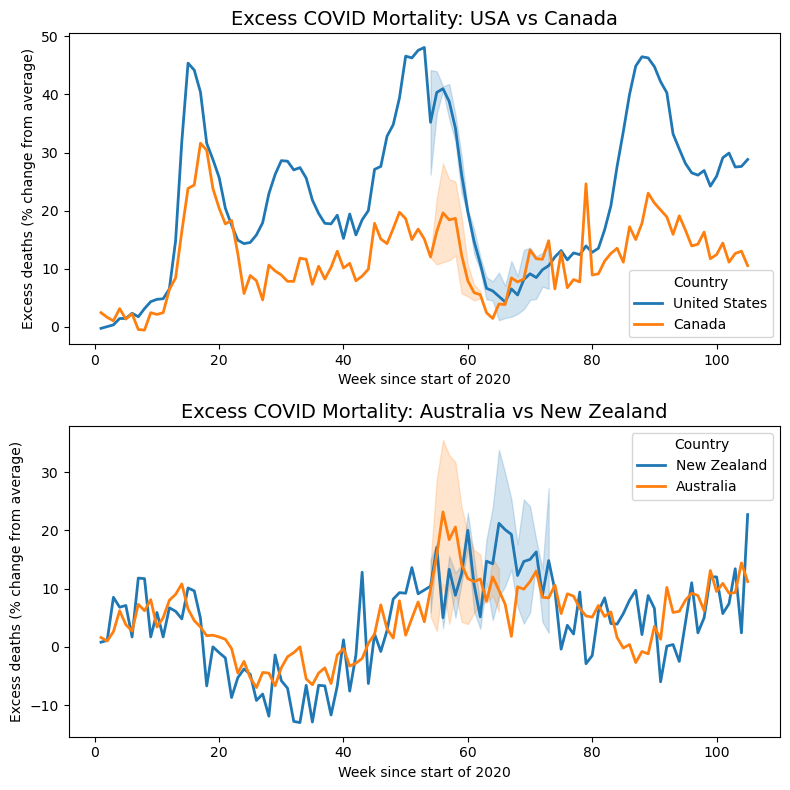

In [181]:
Na = excess_mort.query("Country == 'United States' | Country == 'Canada'")
Oc = excess_mort.query("Country == 'Australia' | Country == 'New Zealand'")

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=False, figsize=(8, 8))
sns.lineplot(data=Na, x="Week_Cont", y='Value', hue="Country", ax=ax1, linewidth=2)
ax1.set_title("Excess COVID Mortality: USA vs Canada", fontsize=14)
ax1.set_xlabel("Week since start of 2020")
ax1.set_ylabel(r"Excess deaths (% change from average)")
sns.lineplot(data=Oc, x="Week_Cont", y='Value', hue="Country", ax=ax2, linewidth=2)
ax2.set_title("Excess COVID Mortality: Australia vs New Zealand", fontsize=14)
ax2.set_xlabel("Week since start of 2020")
ax2.set_ylabel(r"Excess deaths (% change from average)")
plt.tight_layout()
plt.show()

#### Question 2.5

What do you notice about excess mortality through time? Are the patterns different in the US and Canada compared to your other two countries? Describe at least three things you notice. 

**Your response**: Excess mortality seems to feature two main peaks worldwide: one at the start of the pandemic and one about halfway through (winter 2020-2021) and varies quite a bit. The US and Canada sports a very different pattern than Australia and New Zealand outside of this general trend, however. The US and Canada saw much higher peak excess mortality rates - 30 to almost 50% above normal - compared to the Australia and New Zealand. The south Pacific countries even saw excess mortality dip to less than normal levels during the summer of 2020, which the North American countries never saw during this time. The US and Canada saw 3 major peaks spread out over 2020 and 2021 with very sharp increases and decreases, whereas Australia and New Zealand saw much smoother declines into summer 2020, a rise into winter 2020-2021, and a drop off in the middle and end of 2021.

#### Question 2.6

Make another comparison of excess mortality rates of your choice. This should involve a visualization (1 plot or more) and a summary statistic if relevant. Then explain (1) what you can infer from the comparison you made and (2) how you might follow up with a new analysis, including new data collection if needed.

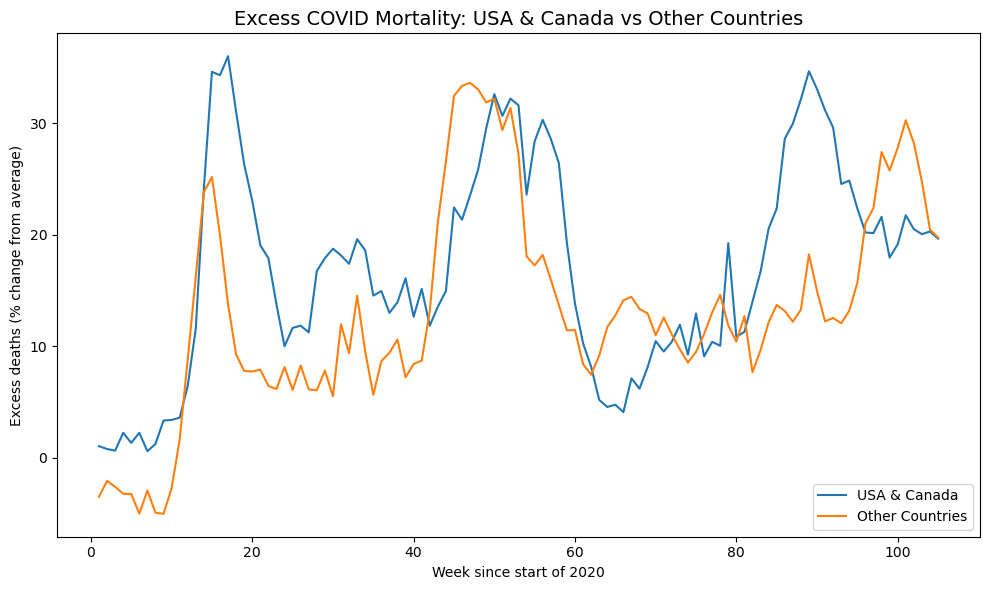

In [182]:
Not_Na = excess_mort.query("Country != 'United States' & Country != 'Canada'").groupby("Week_Cont").agg(
    Value=('Value', 'mean')).reset_index()
Na = Na.groupby("Week_Cont").agg(Value=('Value', 'mean')).reset_index()

plt.figure(figsize=(10, 6))
plt.plot(Na["Week_Cont"], Na['Value'], label="USA & Canada")
plt.plot(Not_Na["Week_Cont"], Not_Na['Value'], label="Other Countries")
plt.legend()
plt.title("Excess COVID Mortality: USA & Canada vs Other Countries", fontsize=14)
plt.xlabel("Week since start of 2020")
plt.ylabel(r"Excess deaths (% change from average)")
plt.tight_layout()
plt.show()

In [183]:
model_na = smf.ols(formula='Value ~ Week_Cont', data=Na).fit()
model_other = smf.ols(formula='Value ~ Week_Cont', data=Not_Na).fit()
print("North America slope:", model_na.params['Week_Cont'])
print("North America p-value:", model_na.pvalues['Week_Cont'])
print("Other countries slope:", model_other.params['Week_Cont'])
print("Other countries p-value:", model_other.pvalues['Week_Cont'])

North America slope: 0.09770742622157721
North America p-value: 0.0011041158435831139
Other countries slope: 0.14686519704491494
Other countries p-value: 2.3441238433322198e-07


**Your response**: I was interested in seeing if North America was distinct in how high the change in excess mortality was after comparing to Australia & New Zealand, so I compared the average of the US + Canada to the other countries in the dataset. This comparison generated similar 2 or 3-peak trends, though the US + Canada a) had a higher summer 2020 peak compared to the rest of the world and b) had a significant peak and fall in late 2021 while the rest of the world saw a steady increase. This could mean the US and Canada had a worse initial response or greater instances of transmission early on and were overall more inconsistent in their quarantine policies, leading to more extreme and sporadic spikes and declines in excess mortality. A linear regression conducted on each group revealed statistically significant slopes; North America saw a smaller slope of 0.0977 compared to the rest of the world at 0.147. This means that while North America was more inconsistent, overall excess mortality increased at a lesser rate in 2020-2021 than the rest of the world. This could infer a faster decrease in mortality due to faster proliferation of vaccines, or that declines after spikes were greater than the rest of the world, bringing down the slope of the regression.
However, the dataset currently contains data from select, mainly wealthy countries. Having a greater variety of countries, and labels for what continent/region they belong to, would be more helpful in discerning if North American trends really were different from other parts of the world. Also, controlling for things like population density and GDP would be helpful, but would require this additional data.

### Part 3: 2018-2019 Oregon Women's Basketball

In DSCI 101, you manipulated data from the Lady Duck's games from the 2019-2019 season; they had an excellent season, with a final four appearance.

As part of your analysis, you determined that there were some aspects of their performance from which one can predict whether they would win a game with high accuracy. In this part, you will derive optimal parameters for two logistic regression models.

A women's collegiate basketball game is divided into four 10-minute quarters; if the game is tied at the end of 4 quarters, 5-minute overtime periods are played until one team is ahead at the end of an overtime period.

The file `uo_women_basketball_18-19.csv` provides the raw statistics for the team's games during the 2018-19 season.

In [184]:
bbgames = pd.read_csv("data/uo_women_basketball_18-19.csv")
bbgames.head(5)

,Opponent,Location,Date,OrQ1,OrQ2,OrQ3,OrQ4,OpQ1,OpQ2,OpQ3,OpQ4,OrOT1,OpOT1
0,Alaska Fairbanks,AWAY,11/06/18,34,26,29,26,9,13,8,6,0,0
1,Syracuse,HOME,11/10/18,20,14,14,27,10,17,17,29,0,0
2,Utah State,AWAY,11/14/18,30,19,20,19,15,13,15,14,0,0
3,Buffalo,HOME,11/18/18,26,23,31,22,16,23,21,22,0,0
4,UC Riverside,HOME,11/23/18,23,29,25,17,11,7,13,13,0,0


#### Question 3.1

Add three columns to `bbgames`:
* OrTotal - Oregon's total points for the game
* OpTotal - the Opponent's total points for the game
* Result - 1 if Oregon won the game, 0 if Oregon lost the game

In [185]:
bbgames["OrTotal"] = bbgames.iloc[:, 3:7].sum(axis=1) + bbgames["OrOT1"]
bbgames["OpTotal"] = bbgames.iloc[:, 7:11].sum(axis=1) + bbgames["OrOT1"]
bbgames["Result"] = (bbgames["OrTotal"] > bbgames["OpTotal"]).astype(int)
bbgames.head()

,Opponent,Location,Date,OrQ1,OrQ2,OrQ3,OrQ4,OpQ1,OpQ2,OpQ3,OpQ4,OrOT1,OpOT1,OrTotal,OpTotal,Result
0,Alaska Fairbanks,AWAY,11/06/18,34,26,29,26,9,13,8,6,0,0,115,36,1
1,Syracuse,HOME,11/10/18,20,14,14,27,10,17,17,29,0,0,75,73,1
2,Utah State,AWAY,11/14/18,30,19,20,19,15,13,15,14,0,0,88,57,1
3,Buffalo,HOME,11/18/18,26,23,31,22,16,23,21,22,0,0,102,82,1
4,UC Riverside,HOME,11/23/18,23,29,25,17,11,7,13,13,0,0,94,44,1


#### Question 3.2

The Lady Ducks were known for outscoring the opposition in the 1st quarter, and again in the 3rd quarter. We are going to use the fractional scoring differential in each quarters as our independent variables for our logistic regression models.

$Q1~fraction = \frac{Oregon~Q1~points~-~Opponent~Q1~points}{Oregon~Q1~points~+~Opponent~Q1~points}$

This fraction varies from -1 to 1

Add 4 columns to `bbgames`:
* Q1fraction - the fractional scoring differential for Q1
* Q2fraction - the fractional scoring differential for Q2
* Q3fraction - the fractional scoring differential for Q3
* Q4fraction - the fractional scoring differential for Q4

In [186]:
def fract(quarter):
    num = bbgames[f"OrQ{quarter}"] - bbgames[f"OpQ{quarter}"]
    den = bbgames[f"OrQ{quarter}"] + bbgames[f"OpQ{quarter}"]
    return num / den

for quarter in range(1,5):
    bbgames[f"Q{quarter}fraction"] = fract(quarter)

bbgames.head()

,Opponent,Location,Date,OrQ1,OrQ2,OrQ3,OrQ4,OpQ1,OpQ2,OpQ3,OpQ4,OrOT1,OpOT1,OrTotal,OpTotal,Result,Q1fraction,Q2fraction,Q3fraction,Q4fraction
0,Alaska Fairbanks,AWAY,11/06/18,34,26,29,26,9,13,8,6,0,0,115,36,1,0.581395,0.333333,0.567568,0.625000
1,Syracuse,HOME,11/10/18,20,14,14,27,10,17,17,29,0,0,75,73,1,0.333333,-0.096774,-0.096774,-0.035714
2,Utah State,AWAY,11/14/18,30,19,20,19,15,13,15,14,0,0,88,57,1,0.333333,0.187500,0.142857,0.151515
3,Buffalo,HOME,11/18/18,26,23,31,22,16,23,21,22,0,0,102,82,1,0.238095,0.000000,0.192308,0.000000
4,UC Riverside,HOME,11/23/18,23,29,25,17,11,7,13,13,0,0,94,44,1,0.352941,0.611111,0.315789,0.133333


#### Question 3.3

Create a scatter plot showing the result on the y-axis and Q1fraction on the x-axis. The limits on the x-axis should be \[-1,1\].

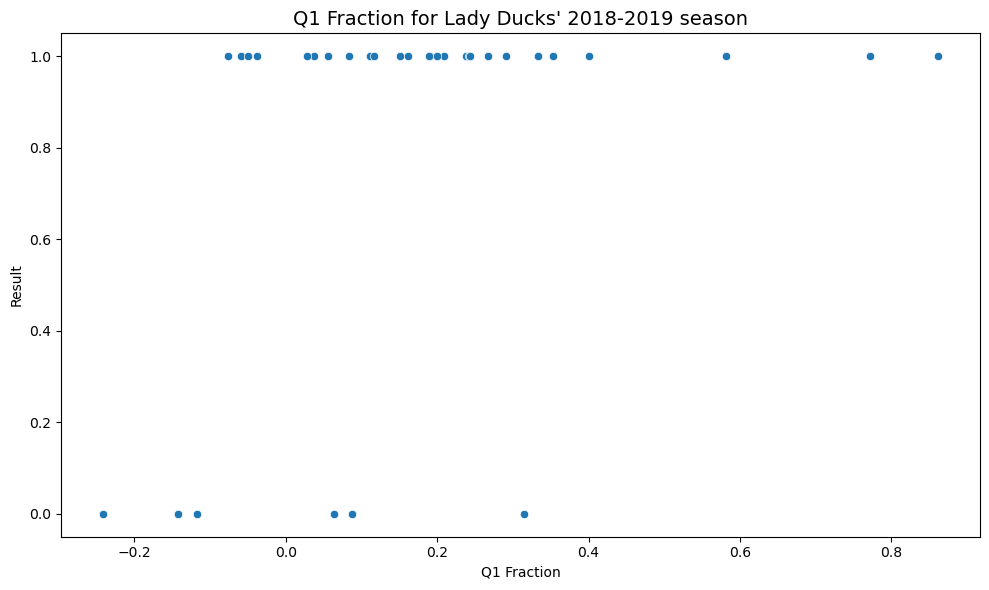

In [187]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=bbgames, x="Q1fraction", y="Result")
plt.title("Q1 Fraction for Lady Ducks' 2018-2019 season", fontsize=14)
plt.xlabel("Q1 Fraction")
plt.ylabel("Result")
plt.tight_layout()
plt.show()

#### Question 3.4

We know that classification, such as winning or losing a game, requires that we use a model that predicts probabilities, and that we arrive at such a model assuming that the log-odds of the probability of yielding a win is linear. Classification is then determined by some choice of threshold (default 0.5).

For a single-feature logistic regression model, we have $P(Y=1|x)~=~\sigma(\theta_1~X_1)$, where $\sigma$ is the sigmoid function.

Define a function `sig(x)` below that returns the value of the sigmoid function for the value `x`. Then plot `sig(25*x)` over the range of \[-1, 1\].

In [188]:
def sig(x):
    return 1 / (1 + np.exp(-x))

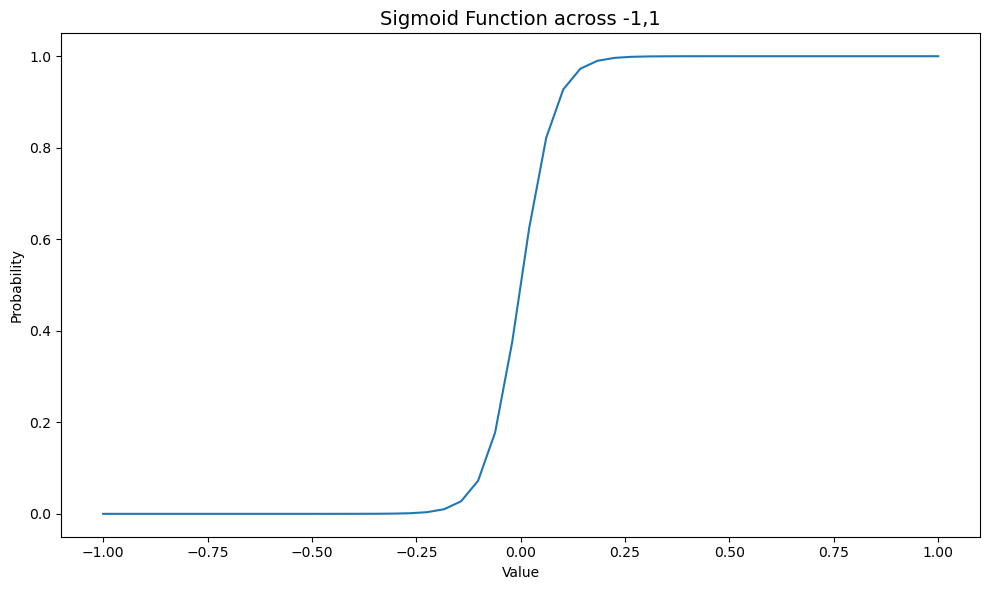

In [189]:
x = np.linspace(-1, 1)
y = sig(25 * x)

plt.figure(figsize=(10, 6))
plt.plot(x, y)
plt.title("Sigmoid Function across -1,1", fontsize=14)
plt.xlabel("Value")
plt.ylabel("Probability")
plt.tight_layout()
plt.show()

#### Question 3.5

Now fit four single-feature logistic regression models *e.g.* $P(Y=1|x)~=~\sigma(\theta_0 + \theta_1~\cdot~Q_1fraction... + \theta_4~\cdot~Q_4fraction)$ for the fractional scoring difference in each of the four quarters and compare them with *k-fold cross-validation* by calculating the mean log loss of each model across the k validation sets. Use whatever *k* you prefer.  You can fit the model yourself with `sigma` and `minimize` and determine the loss yourself, or you can use sklearn's methods.

*Note*: If you use `LogisticRegression()` from 'sklearn', be sure to set the argument `C = 10000` (or higher). `LogisticRegression` implements regularization by default - good when we have multiple predictors and want to optimize for test error. Because we have a small dataset and just want to create the model of best fit on this small dataset, we want to "turn off" regularization. C is the inverse of $\lambda$ i.e. $\lambda = \frac1C$; as C gets larger, the regularization penalty therefore approaches 0. 

In [190]:
Predictors = ["Q1fraction","Q2fraction","Q3fraction","Q4fraction"]

for predictor in Predictors:
    X = bbgames[[predictor]]
    Y = bbgames["Result"]
    X_train, X_test, y_train, y_test = train_test_split(
        X, Y, test_size=0.2, random_state=42)
    model = LogisticRegression(C=20000)
    scores = cross_val_score(model, X_train, y_train, cv=4, scoring='neg_log_loss') # k = 4
    mean_log_loss = -scores.mean()
    print(predictor + f" mean log loss: {mean_log_loss}")


Q1fraction mean log loss: 0.35862900903899486
Q2fraction mean log loss: 0.45077609748440717
Q3fraction mean log loss: 0.45477515451515993
Q4fraction mean log loss: 0.4083230325829479


#### Question 3.6

Now plot the result vs score fractional difference for the quarter associated with your best-fit model (as in q3.3). Extract the coefficient from that model and use this in your sigma function to plot the logistic line of best fit on top of the plot associated with the result vs scoring fraction (of the best quarter).

*Note*: We would normally do cross-validation for model comparison (which you will do in Part 4), but for simplicity just compare train fits for now.

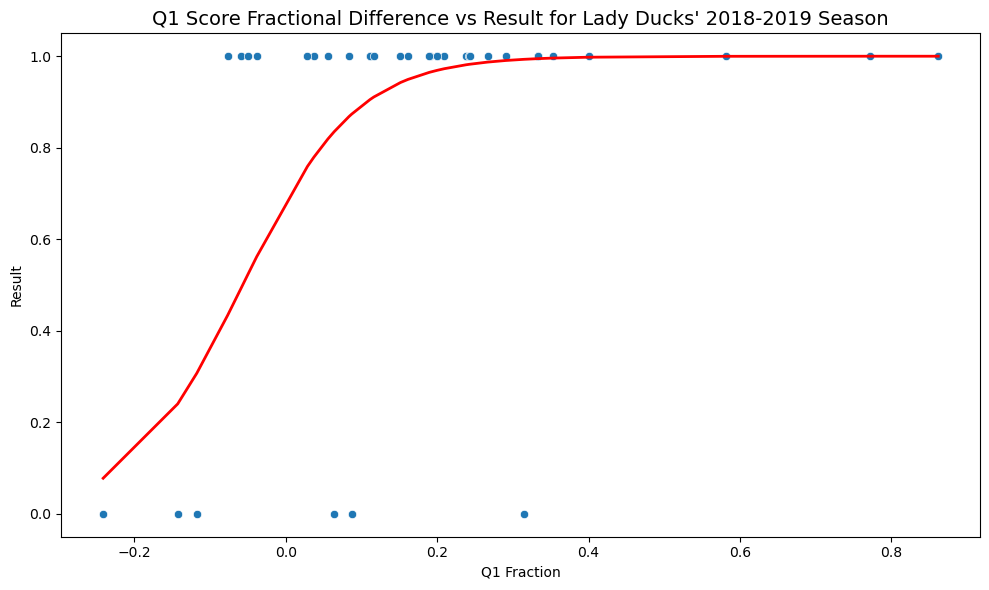

In [191]:
X = bbgames[["Q1fraction"]] # Best quarter was Q1
Y = bbgames["Result"]
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42)
model = LogisticRegression(C=20000)
model.fit(X_train, y_train)

X_sorted = X.sort_values('Q1fraction')
y = sig((model.coef_ * X_sorted.values + model.intercept_).flatten())

plt.figure(figsize=(10, 6))
sns.scatterplot(data=bbgames, x="Q1fraction", y="Result")
plt.plot(X_sorted['Q1fraction'], y, color='red', linewidth=2)
plt.title("Q1 Score Fractional Difference vs Result for Lady Ducks' 2018-2019 Season", fontsize=14)
plt.xlabel("Q1 Fraction")
plt.ylabel("Result")
plt.tight_layout()
plt.show()

#### Question 3.7

Compute the accuracy, precision, and recall of your best model. **Use a threshold of 0.5 for classification**.

In [192]:
# 7 points
y_pred = (y >= 0.5).astype(int)
y_actual = bbgames.loc[X_sorted.index, 'Result'].values
TP = ((y_pred == 1) & (y_actual == 1)).sum()
TN = ((y_pred == 0) & (y_actual == 0)).sum()
FP = ((y_pred == 1) & (y_actual == 0)).sum()
FN = ((y_pred == 0) & (y_actual == 1)).sum()
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = (TP) / (TP + FP)
recall = (TP) / (TP + FN)
(TN, FN, FP, TP, accuracy, precision, recall)

(3, 2, 3, 30, 0.868421052631579, 0.9090909090909091, 0.9375)

#### Question 3.8

Think of the order of your 4 models in terms of their loss. Which quarters were better predictors of a win and which were worse predictors. Why do you expect this might be?

**Your response**: Q1 was the best predictor, followed by Q4, while Q2 and 3 were the worst predictors. Q1 as the best predictor makes sense; after all, the team with the strongest start has the best chance of staying ahead, and with sufficient difference in skill, the outcome of the game is reflected in the Q1 performance of each team. Q4 being the second best predictor was a surprise but could point to the importance and frequency of Q4 comebacks, or perhaps Q4 is when some teams begin to tire or effects from ejections/injuries are felt the most. Q2 and 3, meanwhile, perhaps do not see as much change in the winning prospects of teams because they're situated in the middle of the game and thus don't have the temporally endowed features of the other quarters.

#### Question 3.9

If you were betting money on the outcome of a game, would you prefer to optimize for accuracy, precision, or recall. Explain your answer. 

**Your response**: Given the data for the 2018-2019 season, I would want to optimize for precision. Since I'm betting more on the ducks winning than losing (positives > negatives), a false positive is going to be more likely and more costly than a false negative. Since precision weighs false positives to the greatest degree, that is the feature I'd want to optimize. However, if I did not know the skill of the ducks, I would want to optimize for accuracy, since false positives and negatives would be equally weighted in that situation.

### Question 4

For the final part, we will fit a multiple logistic regression model to predict whether a tissue sample from a biopsied breast mass is maligant or benign using a number of measured characteristics of the sample.

Read in `breast_cancer.csv`. Data from https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

    diagnosis: M = malignant, B = benign
    radius: distances from center to points on the perimeter
    texture: standard deviation of gray-scale values
    smoothness: local variation in radius lengths
    compactness: perimeter^2 / area - 1.0
    symmetry
    fractal dimension: "coastline approximation" - 1


In [193]:
bc = pd.read_csv("data/breast_cancer.csv")
bc.head()

,id,diagnosis,radius_mean,texture_mean,smoothness_mean,compactness_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,smoothness_se,compactness_se,symmetry_se,fractal_dimension_se
0,842302,M,17.99,10.38,0.11840,0.27760,0.2419,0.07871,1.0950,0.9053,0.006399,0.04904,0.03003,0.006193
1,842517,M,20.57,17.77,0.08474,0.07864,0.1812,0.05667,0.5435,0.7339,0.005225,0.01308,0.01389,0.003532
2,84300903,M,19.69,21.25,0.10960,0.15990,0.2069,0.05999,0.7456,0.7869,0.006150,0.04006,0.02250,0.004571
3,84348301,M,11.42,20.38,0.14250,0.28390,0.2597,0.09744,0.4956,1.1560,0.009110,0.07458,0.05963,0.009208
4,84358402,M,20.29,14.34,0.10030,0.13280,0.1809,0.05883,0.7572,0.7813,0.011490,0.02461,0.01756,0.005115


In [194]:
y = bc["diagnosis"].replace({"M":1,"B":0})
X = bc.drop(["id","diagnosis"], axis = 1)

C:\Users\jacob\AppData\Local\Temp\ipykernel_23660\3366068328.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = bc["diagnosis"].replace({"M":1,"B":0})


#### Question 4.1

The plan is to determine which of the anatomical characteristics of the tissue sample are the most important for predicting malignancy. (1) Standardize your features (X) and (2) split your data into train and test sets.

In [195]:
X = bc.drop(["id", "diagnosis"], axis=1)
Y = bc["diagnosis"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [196]:
X_train, X_holdout, y_train, y_holdout = train_test_split(
    X_scaled, Y, 
    test_size=0.2,
    random_state=42
)

#### Question 4.2

Now compare models of different strengths of regularization (provided) using *k-fold cross-validation*. Use whatever *k* you prefer. The `C =` argument is how you set the penalty when creating the model.

In [197]:
Cs = [.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
train_error = []
test_error = []

for c in Cs:
    model = LogisticRegression(C=c)
    train_scores = cross_val_score(model, X_train, y_train, cv=4, scoring='neg_log_loss') # k = 4
    train_error.append(-train_scores.mean())

    model.fit(X_train, y_train)
    y_pred = model.predict_proba(X_holdout)
    test_error.append(log_loss(y_holdout, y_pred))

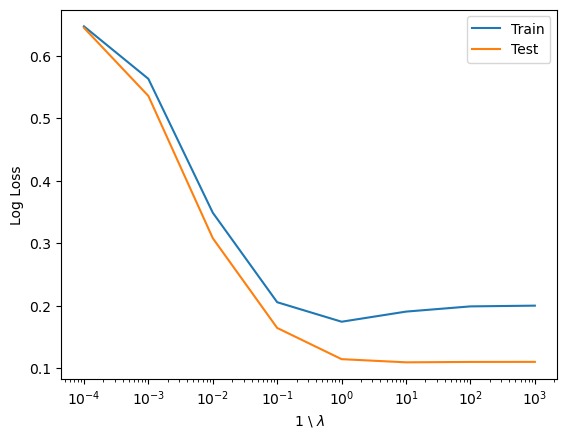

In [198]:
# Plot the two errors
sns.lineplot(x = Cs, y = train_error, label = "Train")
plt.xscale('log')
sns.lineplot(x = Cs, y = test_error, label = "Test")
plt.xscale('log')
plt.ylabel("Log Loss")
plt.xlabel("1 \ $\lambda$");

Keeping in mind that `C` in `LogisticRegression` is the inverse of our regularization parameter $\lambda$, what can we infer about the effect of regularization on the quality of the model? Does regulating the parameters improve or worsen the fit of the model?

Doing the next question might help you with this question if you're unsure. 

**Your response:** Larger C values/smaller $\lambda$ values improve the quality of the model in both the training and test sets, though the returns diminish over time (flattens or worsens at ~1), seen with the decreasing log loss of the models as C grows. We can infer that regularization has a helpful effect minimizing loss, likely preventting overfitting and/or underfitting.

#### Question 4.3

When fitting models at different regularization strengths in 4.2, record the values of the coefficients (`model.coef_`) at each strength. Create a lineplot showing the change in the estimated parameters for each variable across the range of regularization strengths. Your x-axis should be the same as the above plot. 

In [199]:
Cs = [.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
model_coefs = {var: [] for var in X.columns}

for c in Cs:
    for i, var in enumerate(X.columns):
        model = LogisticRegression(C=c)
        model.fit(X_scaled[:, i].reshape(-1, 1), Y)
        model_coefs[var].append(model.coef_[0][0])


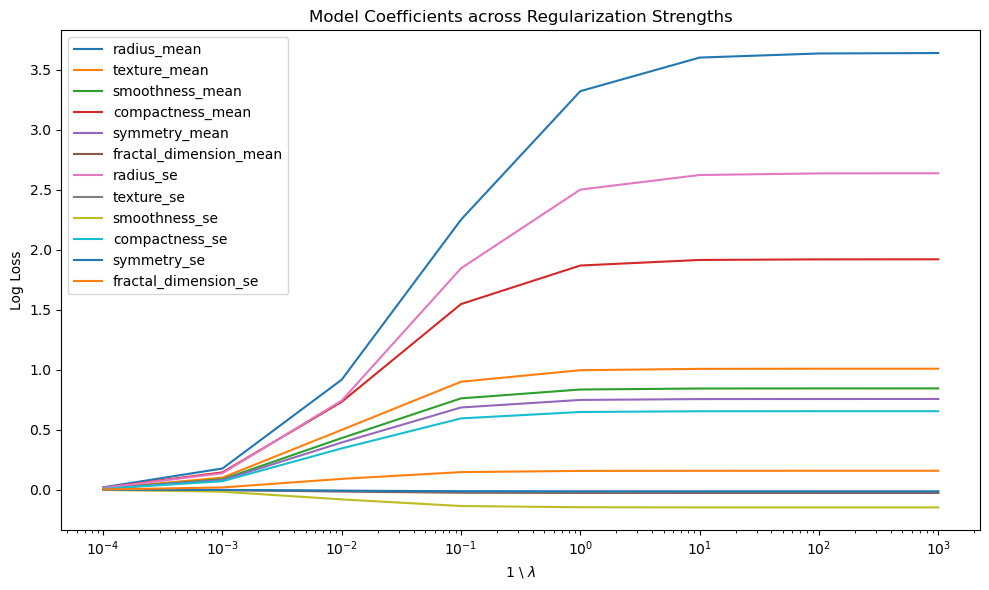

In [200]:
plt.figure(figsize=(10, 6))
for var in model_coefs.keys():
    plt.plot(Cs, model_coefs[var], label = var)
plt.xscale('log')
plt.xscale('log')
plt.ylabel("Log Loss")
plt.xlabel("1 \ $\lambda$");
plt.title("Model Coefficients across Regularization Strengths")
plt.legend()
plt.tight_layout()
plt.show()

Based on the initial coefficients of your standardized variables, as well as the rate at which they shrink with regularization, which variable appear the most important for predicting malignancy?

**Your response:** Based on the initial coefficients of the standardized variables, radius_mean (mean of distances from center to points on the perimeter) seems to be the best predictor of malignancy, as it grows the fastest as regularization decreases.

# Submission

You are now done with the final (and DSCI 311!). 

Make sure you have run all cells in your notebook in order. Then execute the following in the File menu

* Save and Checkpoint
* Close and Halt

Then upload your notebook to Canvas Assignment Final.